# GAVD Exploration Notebook - Extract Features

@Author: Alex Mui

@Email: jiamingmui@gmail.com

In [1]:
import sys
import pandas as pd
from typing import Dict, List
from pathlib import Path

project_root = Path.cwd().parent

# Add the project root to the Python path
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: /Users/alexmui/dev/alexpose


In [2]:
from ambient.utils.csv_parser import parse_csv_with_dicts
from ambient.gavd import GaitDataProcessor, GAVDDataLoader, PoseDataConverter
from ambient.gavd.pose_estimators import OpenPoseEstimator

## Step 1: Load Sequences of GAVD Data

In [3]:
ONE_SEQUENCE_PATH = Path(project_root, "data", "GAVD_Clinical_Annotations_1.1.csv")

In [4]:
loader = GAVDDataLoader()
df = loader.load_gavd_data(ONE_SEQUENCE_PATH)
sequences = loader.organize_by_sequence(df)
len(sequences)

2026-01-13 12:43:55.426 | INFO     | ambient.gavd.gavd_processor:load_gavd_data:345 - Loading GAVD data from: /Users/alexmui/dev/alexpose/data/GAVD_Clinical_Annotations_1.1.csv
2026-01-13 12:43:55.449 | WARNING  | ambient.gavd.gavd_processor:_download_youtube_videos:290 - YouTube cookies file not found at /Users/alexmui/dev/alexpose/config/yt_cookies.txt
2026-01-13 12:43:55.450 | INFO     | ambient.utils.youtube_cache:_prepare_download_list:227 - Already cached (skipping): /Users/alexmui/dev/alexpose/data/youtube/B5hrxKe2nP8.mp4
2026-01-13 12:43:55.451 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:302 - YouTube cache attempted: 1
2026-01-13 12:43:55.451 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:303 - YouTube cache skipped: 1
2026-01-13 12:43:55.451 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:304 - YouTube cache downloaded: 0
2026-01-13 12:43:55.451 | INFO     | ambient.gavd.gavd_processor:_download_youtube_videos:308 - Y

2

In [5]:
type(sequences)

dict

In [6]:
sequences.keys()

dict_keys(['cljan9b4p00043n6ligceanyp', 'cljanb45y00083n6lmh1qhydd'])

## Step 2: Analyze Sequence Structure

In [7]:
def analyze_sequence_structure(sequences: Dict[str, pd.DataFrame]):
    """
    Analyze the structure of sequences to understand the data organization.
    
    Args:
        sequences (Dict[str, pd.DataFrame]): Organized sequence data
    """
    print("\n" + "="*50)
    print("SEQUENCE STRUCTURE ANALYSIS")
    print("="*50)
    
    for seq_id, seq_data in sequences.items():
        print(f"\nSequence: {seq_id}")
        print(f"  Total frames: {len(seq_data)}")
        print(f"  Frame numbers: {seq_data['frame_num'].tolist()}")
        
        # Show first few frames
        print(f"  First 3 frames:")
        for i, (_, row) in enumerate(seq_data.head(3).iterrows()):
            bbox = row['bbox']
            if isinstance(bbox, dict):
                print(f"    Frame {row['frame_num']}: bbox at ({bbox.get('left', 0):.1f}, {bbox.get('top', 0):.1f})")
        
        # Check if frames are consecutive
        frame_nums = seq_data['frame_num'].astype(int).values
        is_consecutive = all(frame_nums[i+1] - frame_nums[i] == 1 for i in range(len(frame_nums)-1))
        print(f"  Consecutive frames: {is_consecutive}")


In [8]:
analyze_sequence_structure(sequences)


SEQUENCE STRUCTURE ANALYSIS

Sequence: cljan9b4p00043n6ligceanyp
  Total frames: 512
  Frame numbers: [1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764, 1765, 1766, 1767, 1768, 1769, 1770, 1771, 1772, 1773, 1774, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 19

## Step 3: Visualize Frames


### 3.1  First Sequence

In [9]:
# Example: Visualize a specific frame
# Get the first sequence ID
first_seq_id = list(sequences.keys())[0]
first_frame_num = sequences[first_seq_id]['frame_num'].iloc[0]

In [10]:
# How many frames are in the first sequence?
len(sequences[first_seq_id])

512

Scaled bbox: annotation=1280x720, video=640x360, scale=(0.500, 0.500)
Bbox drawn: left=76, top=62, width=119, height=250


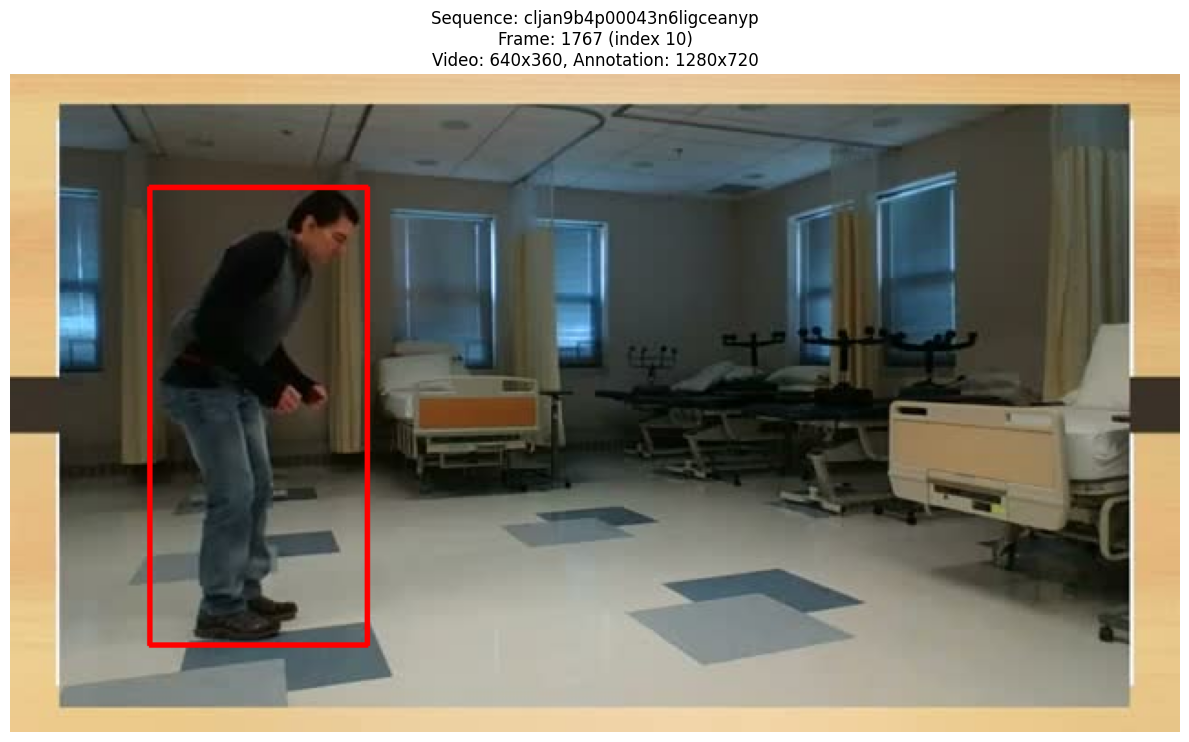

Displayed frame 1767 from sequence cljan9b4p00043n6ligceanyp


In [11]:
from notebooks.utils.viz import visualize_frame

# visualize_frame(sequences, first_seq_id, int(first_frame_num), draw_bbox=True)
visualize_frame(project_root, sequences, seq_id=first_seq_id, frame_index=10, show_bbox=True)


### 3.2  Second Sequence

In [12]:
# Example: Visualize a specific frame
second_seq_id = list(sequences.keys())[1]
# How many frames are in the second sequence?
len(sequences[second_seq_id])

215

Scaled bbox: annotation=1280x720, video=640x360, scale=(0.500, 0.500)
Bbox drawn: left=402, top=64, width=123, height=242


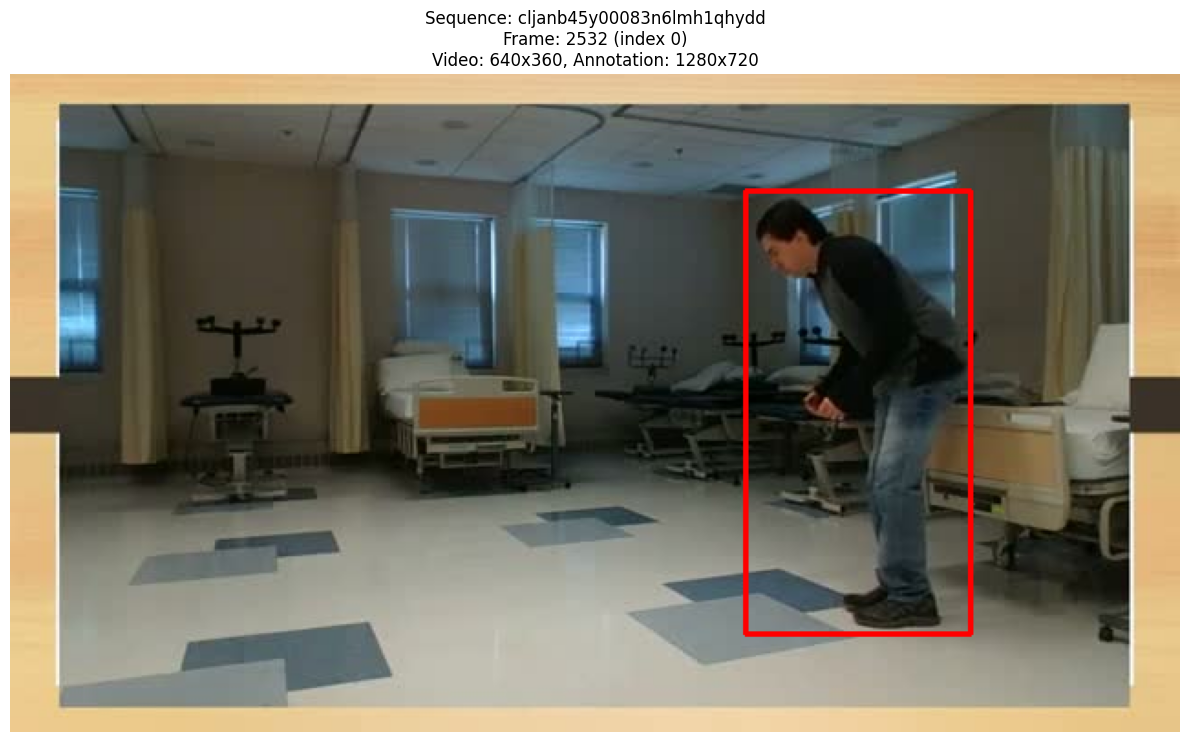

Displayed frame 2532 from sequence cljanb45y00083n6lmh1qhydd


In [13]:
# Visualize the frame
#visualize_frame(sequences, second_seq_id, int(second_frame_num), draw_bbox=True)
visualize_frame(project_root, sequences, second_seq_id, frame_index=0, show_bbox=True)

## Step 4: Pose Estimation using MediaPipe

Reference source: [MediaPipe](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker)

2026-01-13 12:43:56.964 | INFO     | ambient.gavd.pose_estimators:__init__:145 - MediaPipe pose estimator initialized with model: /Users/alexmui/dev/alexpose/data/models/pose_landmarker_lite.task


✅ Using MediaPipeEstimator from ambient package
🎯 MediaPipe detects 33 landmarks
✅ Model already exists: /Users/alexmui/dev/alexpose/data/models/pose_landmarker_lite.task
✅ MediaPipeEstimator created successfully
📍 Model available: True
🔍 Running pose detection with MediaPipeEstimator...


I0000 00:00:1768337037.102945 5742709 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1768337037.157357 5742711 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


keypoint: <class 'list'>, frame: <class 'numpy.ndarray'>


W0000 00:00:1768337037.167029 5742711 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337037.187305 5742712 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


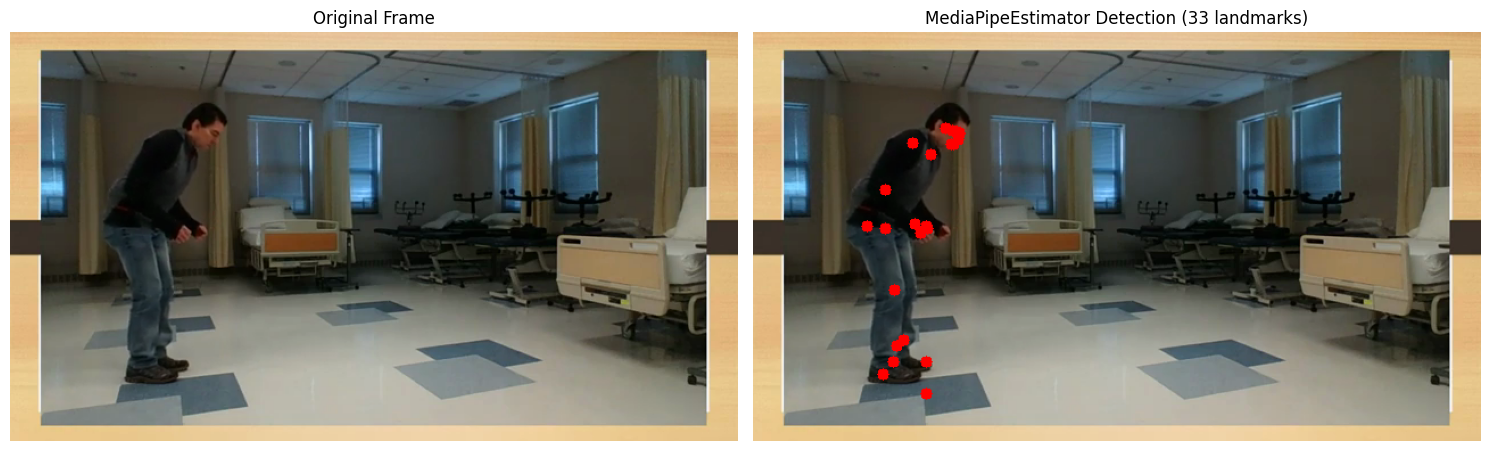

✅ SUCCESS! Detected 33 landmarks
👁️ 27 landmarks are visible (confidence > 0.5)

📍 Sample keypoints:
  NOSE: (180.8, 95.8) confidence=0.999
  LEFT_EYE_INNER: (181.8, 90.3) confidence=0.999
  LEFT_EYE: (181.8, 90.0) confidence=0.999
  LEFT_EYE_OUTER: (181.7, 89.8) confidence=1.000
  RIGHT_EYE_INNER: (180.6, 89.7) confidence=0.999


In [14]:
from utils.keypoints import get_keypoints, visualize_keypoints

keypoints, frame = get_keypoints(project_root, sequences)
visualize_keypoints(keypoints, frame)

### Visualize with Connected Components

I0000 00:00:1768337037.302655 5742720 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337037.355985 5742727 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 43 | Frame number: 1800
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=151.21428571428572, top=123.85714285714286, w=267.85714285714283, h=510.57142857142856
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=75.6, top=61.9, w=133.9, h=255.3
   ✅ Bounding box drawn with correct scaling


W0000 00:00:1768337037.370727 5742726 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


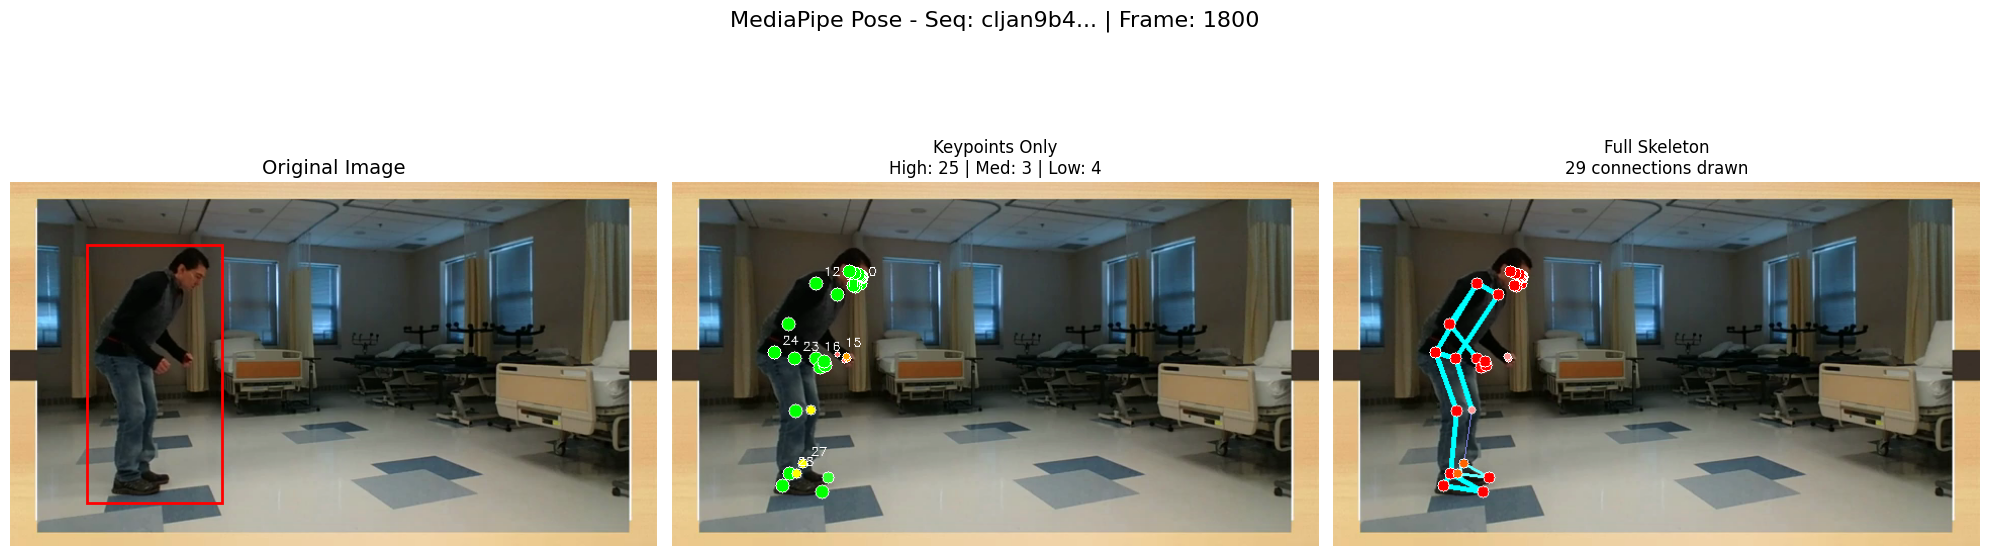


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 27
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 3
   Low confidence (0.2-0.4): 4
   Average confidence: 0.807
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.996
   Upper body (11-22): 0.629
   Lower body (23-32): 0.814


In [15]:
from utils.keypoints import extract_pose_from_sequence, pose_estimation_for_frames, pose_estimation_all_sequences

# Test specific sequence and frame number
result = extract_pose_from_sequence(
    project_root,
    sequence_data=sequences[first_seq_id],
    frame_num=1800
)


I0000 00:00:1768337037.534737 5742745 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 200 | Frame number: 1957
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=320.8493150684931, top=120.0, w=233.4246575342466, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=160.4, top=60.0, w=116.7, h=248.5
   ✅ Bounding box drawn with correct scaling


W0000 00:00:1768337037.585872 5742747 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337037.594527 5742748 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


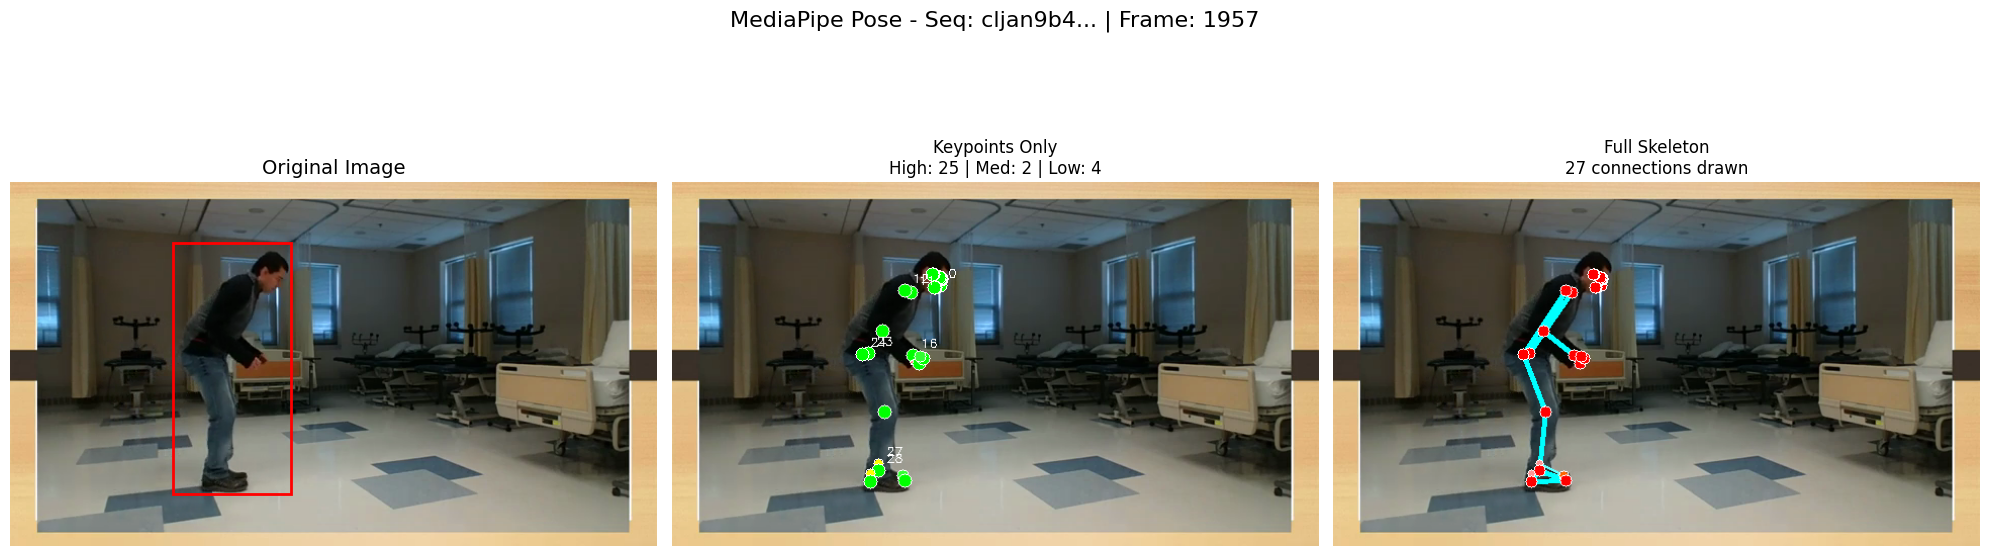


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 25
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 2
   Low confidence (0.2-0.4): 4
   Average confidence: 0.768
   Skeleton connections drawn: 27

Body Part Confidence:
   Face (0-10): 0.988
   Upper body (11-22): 0.570
   Lower body (23-32): 0.765


In [16]:
result = extract_pose_from_sequence(
    project_root,
    sequence_data=sequences[first_seq_id],
    frame_index=200
)

I0000 00:00:1768337037.781558 5742763 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 25 | Frame number: 1782
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=150.73684210526315, top=124.34210526315789, w=253.6578947368421, h=506.2105263157895
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=75.4, top=62.2, w=126.8, h=253.1
   ✅ Bounding box drawn with correct scaling


W0000 00:00:1768337037.832946 5742766 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337037.840477 5742764 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


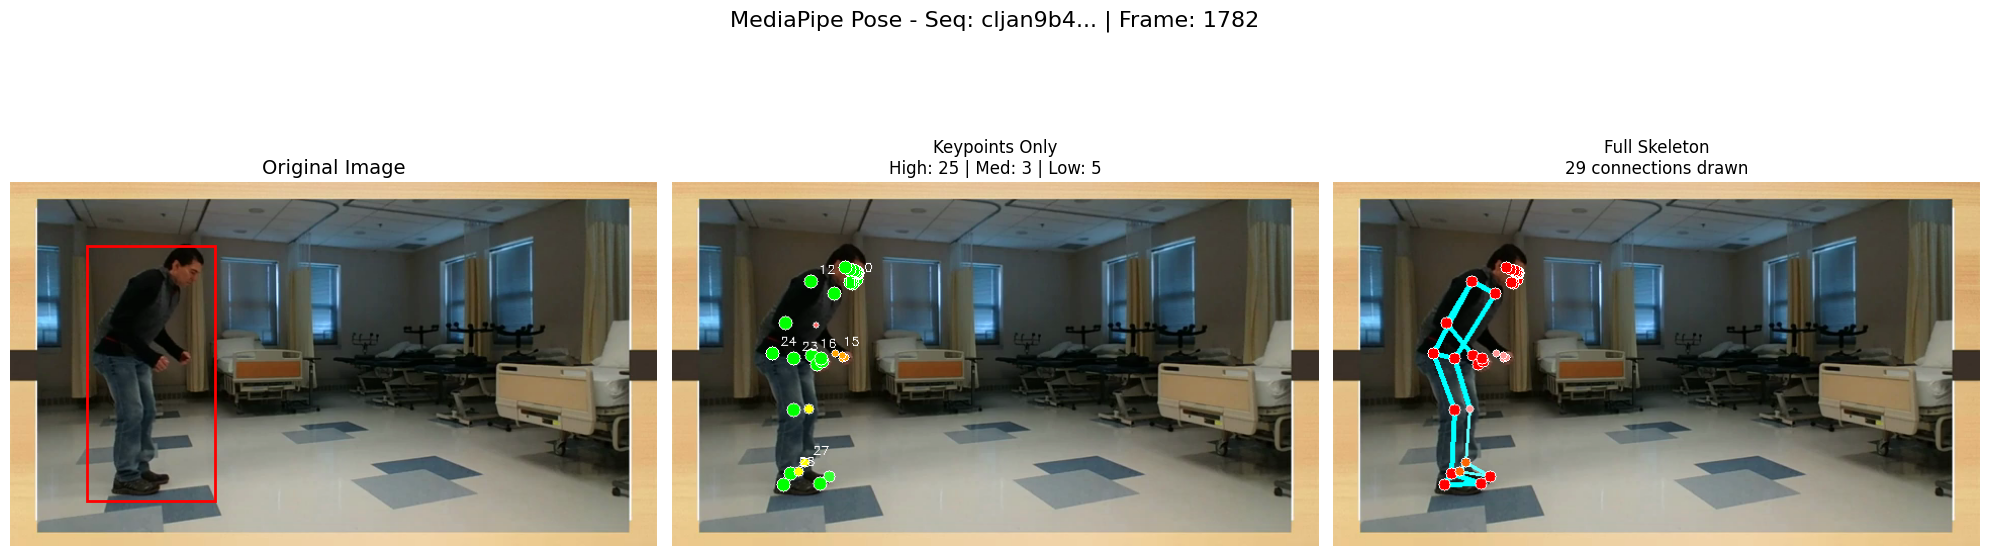


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 27
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 3
   Low confidence (0.2-0.4): 5
   Average confidence: 0.818
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.996
   Upper body (11-22): 0.654
   Lower body (23-32): 0.819


In [17]:
result = extract_pose_from_sequence(
    project_root,
    sequence_data=sequences[first_seq_id],
    frame_index=25,
    use_bbox=True,
    confidence_threshold=0.5
)

### Batch Testing

🎯 Testing 3 specific frame indices: [0, 100, 200]

--- Testing frame 1/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 0 | Frame number: 1757
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=156.0, top=125.0, w=228.0, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=78.0, top=62.5, w=114.0, h=248.5
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337038.081544 5742785 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337038.132818 5742788 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337038.140325 5742788 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


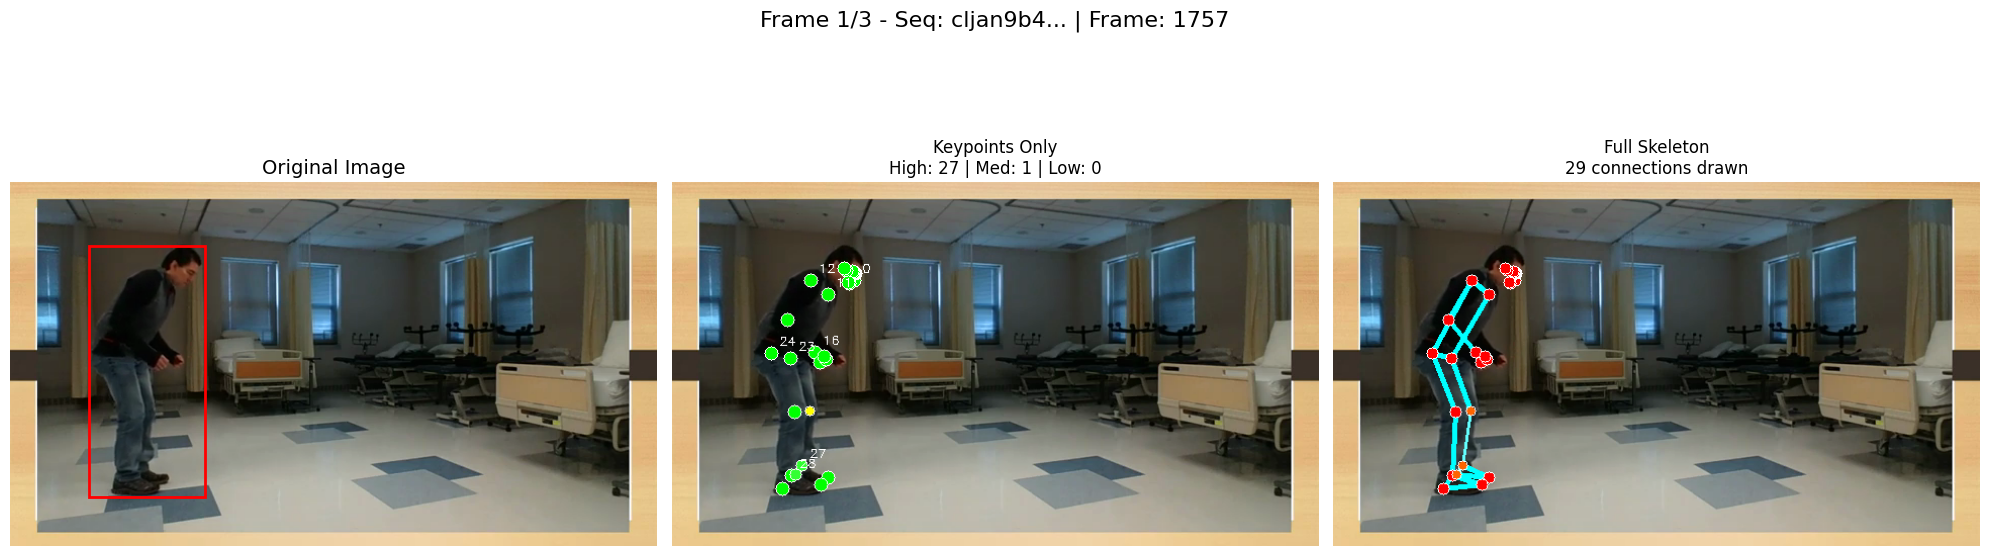


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 28
   High confidence (>0.7): 27
   Medium confidence (0.4-0.7): 1
   Low confidence (0.2-0.4): 0
   Average confidence: 0.794
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.995
   Upper body (11-22): 0.561
   Lower body (23-32): 0.853

--- Testing frame 2/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 100 | Frame number: 1857
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=187.85714285714286, top=122.22857142857143, w=277.6285714285714, h=505.6857142857143
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=93.9, top=61.1, w=138.8, h=252.8
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337038.303974 5742803 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337038.355896 5742806 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337038.363355 5742810 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


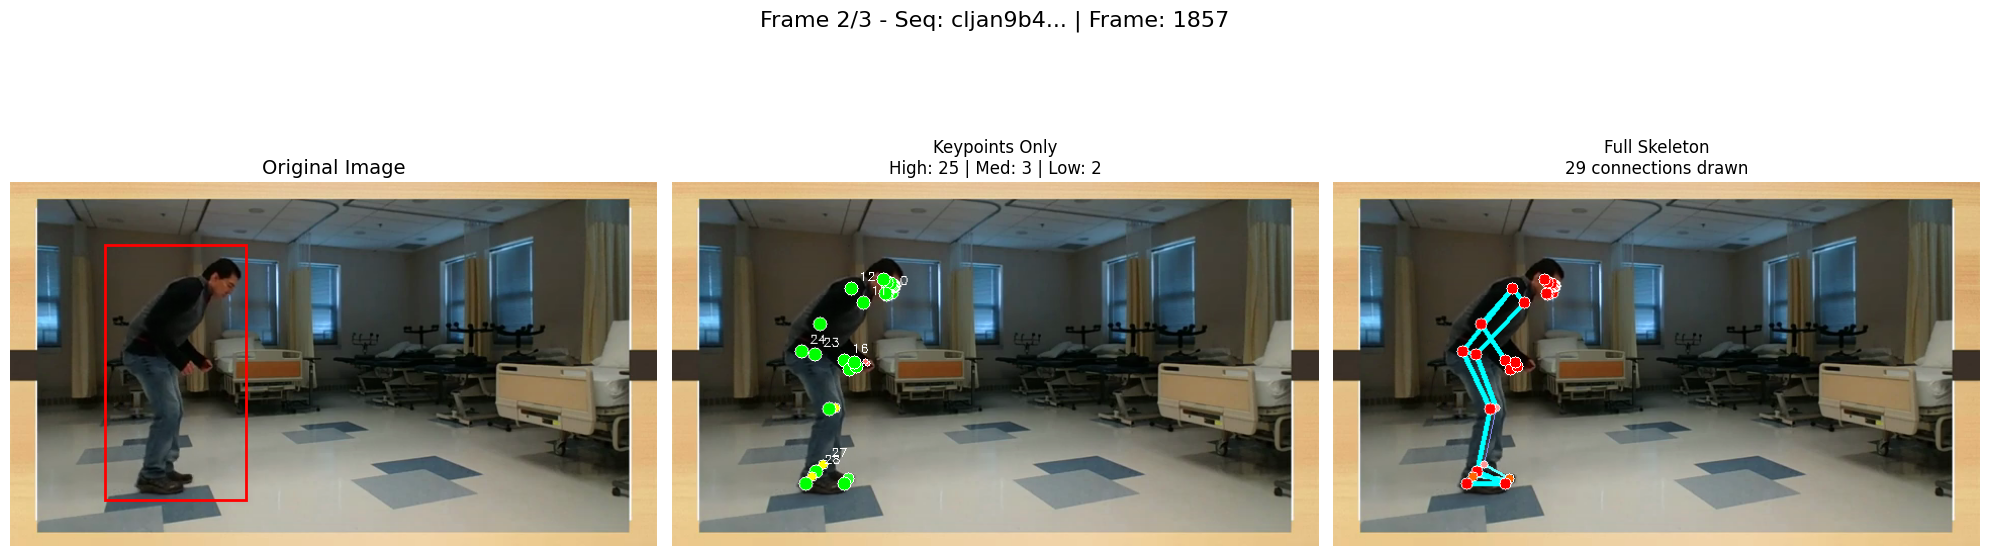


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 26
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 3
   Low confidence (0.2-0.4): 2
   Average confidence: 0.786
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.998
   Upper body (11-22): 0.582
   Lower body (23-32): 0.797

--- Testing frame 3/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 200 | Frame number: 1957
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=320.8493150684931, top=120.0, w=233.4246575342466, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=160.4, top=60.0, w=116.7, h=248.5
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337038.528895 5742820 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337038.581775 5742822 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337038.589499 5742822 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


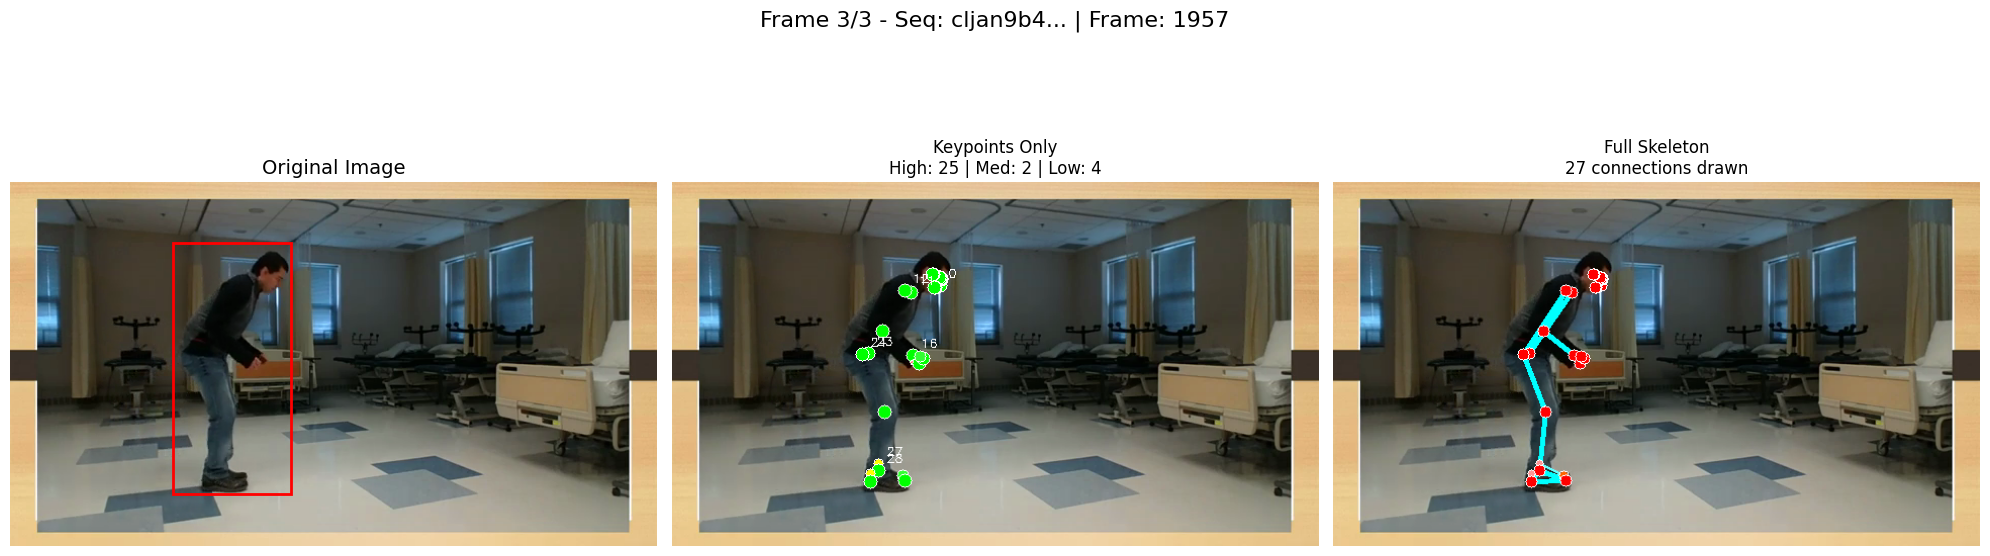


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 25
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 2
   Low confidence (0.2-0.4): 4
   Average confidence: 0.768
   Skeleton connections drawn: 27

Body Part Confidence:
   Face (0-10): 0.988
   Upper body (11-22): 0.570
   Lower body (23-32): 0.765

📊 SUMMARY - Tested 3 frames from sequence cljan9b4p00043n6ligceanyp
   ✅ Successful detections: 3/3
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.783


In [18]:
# Test multiple specific frames
results = pose_estimation_for_frames(
    project_root=project_root,
    sequence_data=sequences[first_seq_id],
    frame_indices=[0, 100, 200]
)

🎯 Testing 3 specific frame numbers: [1757, 1850, 1950]

--- Testing frame 1/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 0 | Frame number: 1757
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=156.0, top=125.0, w=228.0, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=78.0, top=62.5, w=114.0, h=248.5
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337038.770251 5742838 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337038.822362 5742839 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337038.830299 5742839 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


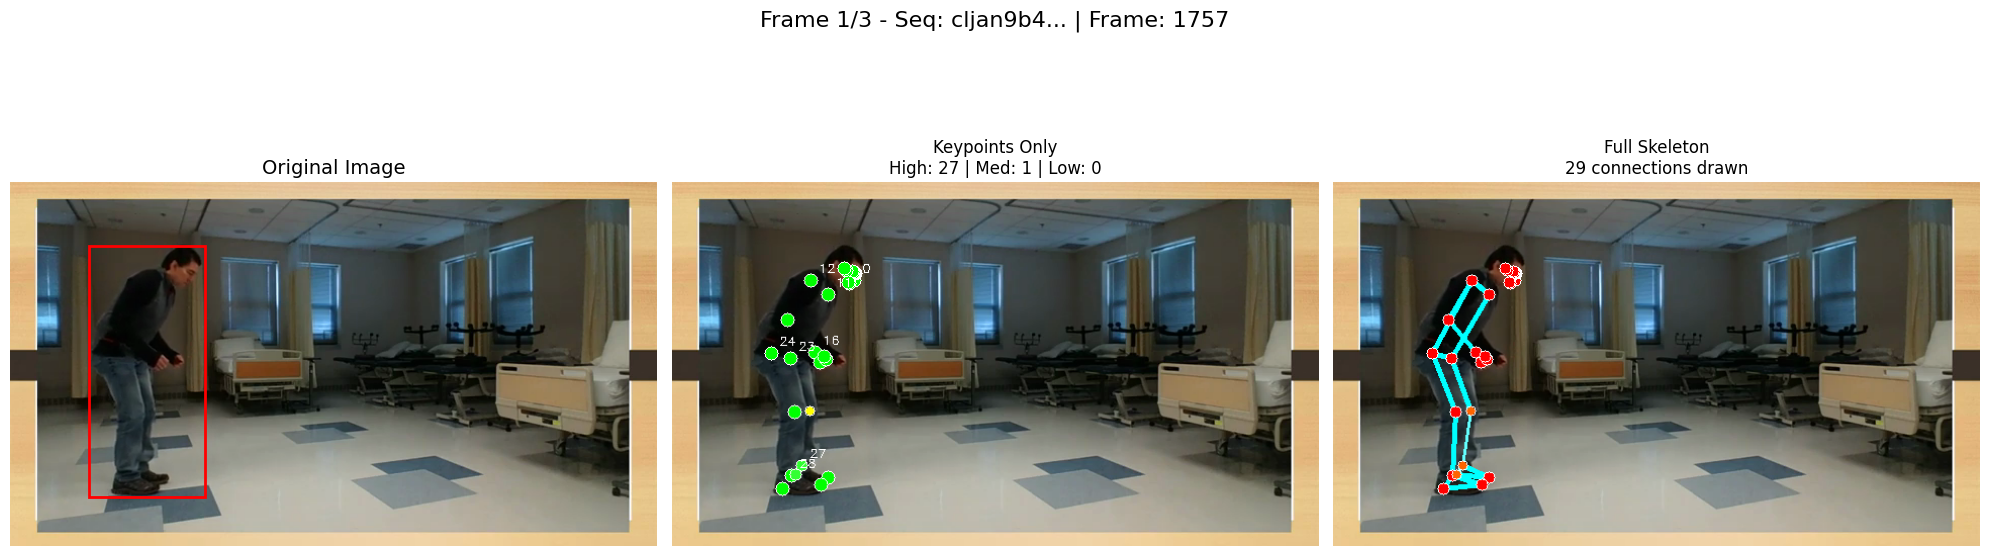


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 28
   High confidence (>0.7): 27
   Medium confidence (0.4-0.7): 1
   Low confidence (0.2-0.4): 0
   Average confidence: 0.794
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.995
   Upper body (11-22): 0.561
   Lower body (23-32): 0.853

--- Testing frame 2/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 93 | Frame number: 1850
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=183.35714285714286, top=122.42857142857143, w=276.42857142857144, h=506.2857142857142
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=91.7, top=61.2, w=138.2, h=253.1
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337039.053975 5742864 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.108128 5742866 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.115647 5742869 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


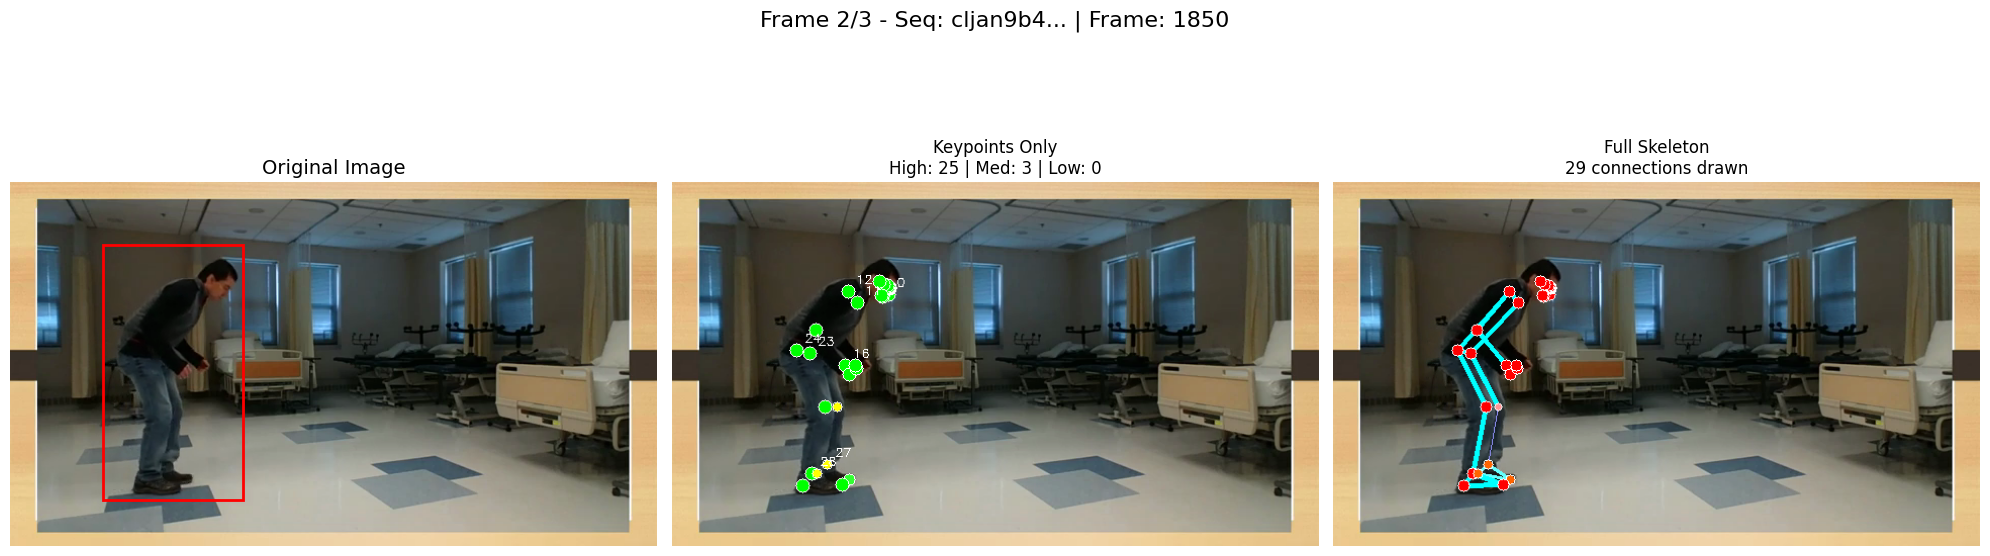


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 27
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 3
   Low confidence (0.2-0.4): 0
   Average confidence: 0.787
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.998
   Upper body (11-22): 0.578
   Lower body (23-32): 0.805

--- Testing frame 3/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 193 | Frame number: 1950
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=314.52054794520546, top=120.0, w=230.26027397260276, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=157.3, top=60.0, w=115.1, h=248.5
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337039.296044 5742887 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.350153 5742888 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.357972 5742888 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


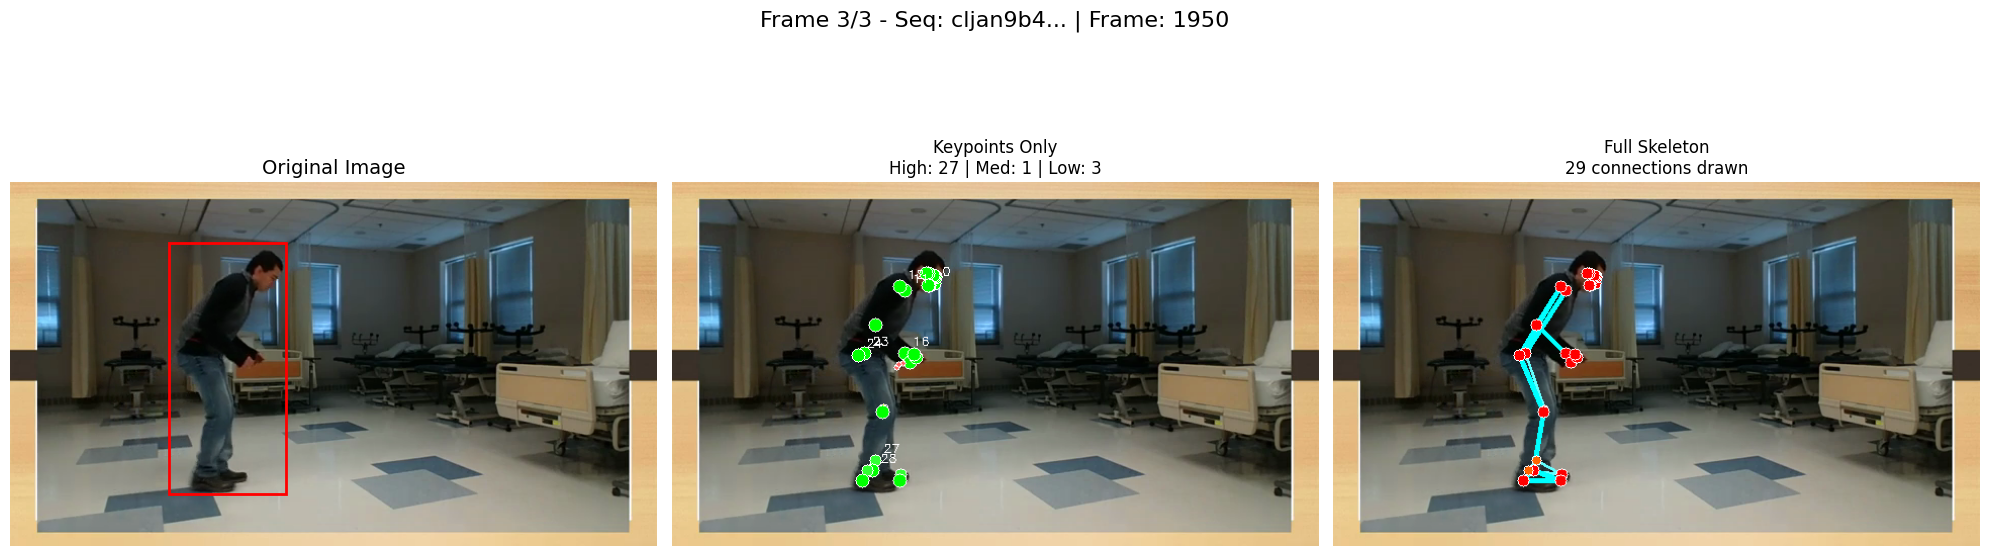


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 27
   High confidence (>0.7): 27
   Medium confidence (0.4-0.7): 1
   Low confidence (0.2-0.4): 3
   Average confidence: 0.794
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.993
   Upper body (11-22): 0.581
   Lower body (23-32): 0.830

📊 SUMMARY - Tested 3 frames from sequence cljan9b4p00043n6ligceanyp
   ✅ Successful detections: 3/3
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.792


In [19]:
# Test specific frame numbers
results = pose_estimation_for_frames(
    project_root=project_root,
    sequence_data=sequences[first_seq_id],
    frame_nums=[1757, 1850, 1950]
)

In [20]:
# Test specific frame numbers
results = pose_estimation_for_frames(
    project_root=project_root,
    sequence_data=sequences[first_seq_id],
    max_frames=3,
    show_each=False  # Don't show each visualization
)

🎯 Auto-selected 3 frames from sequence (total: 512)

--- Testing frame 1/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 0 | Frame number: 1757
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 2/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 170 | Frame number: 1927


I0000 00:00:1768337039.541948 5742905 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.596065 5742908 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.603843 5742908 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1768337039.661792 5742922 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.713599 5742924 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.721121 5742924 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 3/3 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 340 | Frame number: 2097
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

📊 SUMMARY - Tested 3 frames from sequence cljan9b4p00043n6ligceanyp
   ✅ Successful detections: 3/3
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.802


I0000 00:00:1768337039.777211 5742939 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.829856 5742941 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.837469 5742945 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


🔍 Exploring pose detection across 2 sequences
   Testing up to 2 frames per sequence

SEQUENCE 1/2: cljan9b4p00043n6ligceanyp
🎯 Auto-selected 2 frames from sequence (total: 512)

--- Testing frame 1/2 ---


I0000 00:00:1768337039.895584 5742958 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337039.947750 5742961 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337039.955530 5742960 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 0 | Frame number: 1757
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=156.0, top=125.0, w=228.0, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=78.0, top=62.5, w=114.0, h=248.5
   ✅ Bounding box drawn with correct scaling


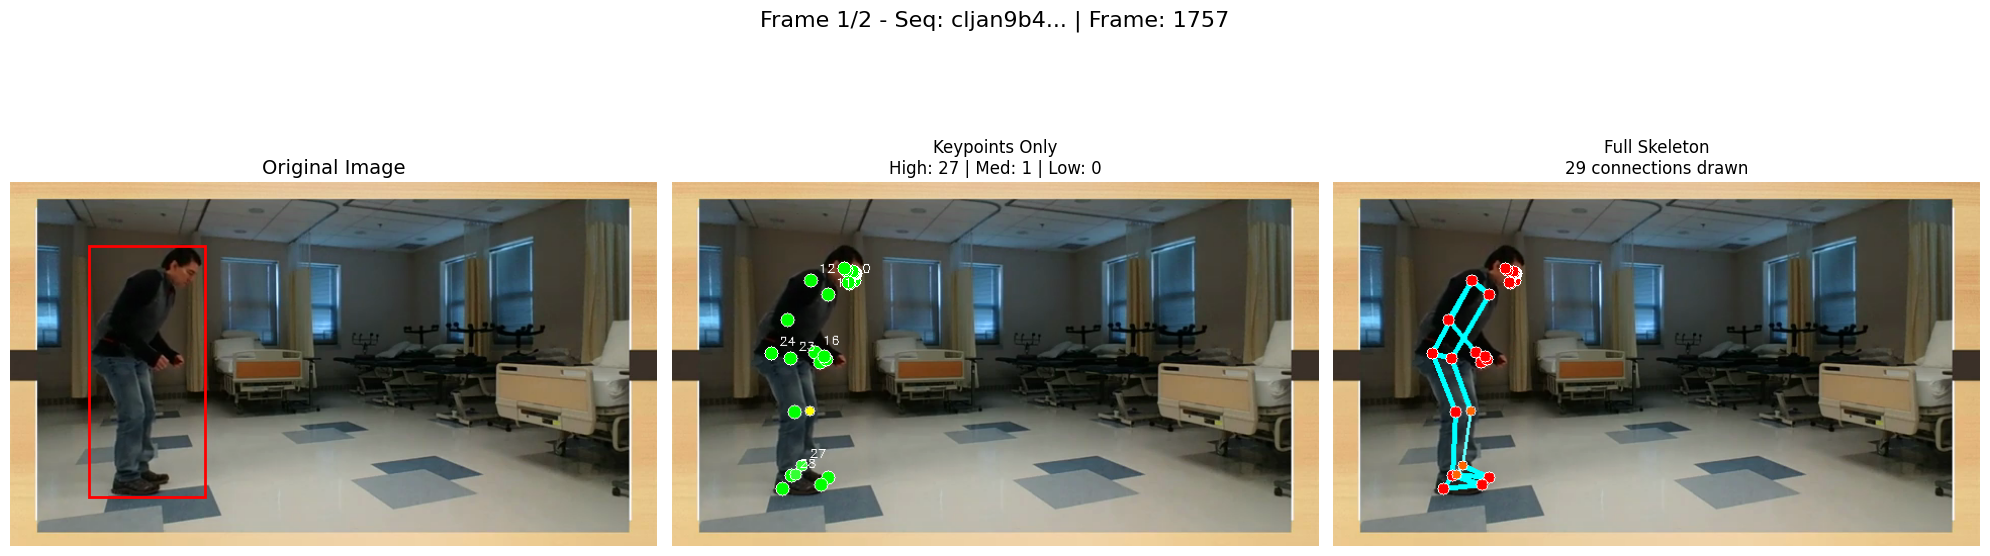


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 28
   High confidence (>0.7): 27
   Medium confidence (0.4-0.7): 1
   Low confidence (0.2-0.4): 0
   Average confidence: 0.794
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.995
   Upper body (11-22): 0.561
   Lower body (23-32): 0.853

--- Testing frame 2/2 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 256 | Frame number: 2013
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=371.47945205479454, top=120.0, w=258.73972602739724, h=497.0
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=185.7, top=60.0, w=129.4, h=248.5
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337040.171285 5742978 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337040.227459 5742982 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337040.235716 5742983 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


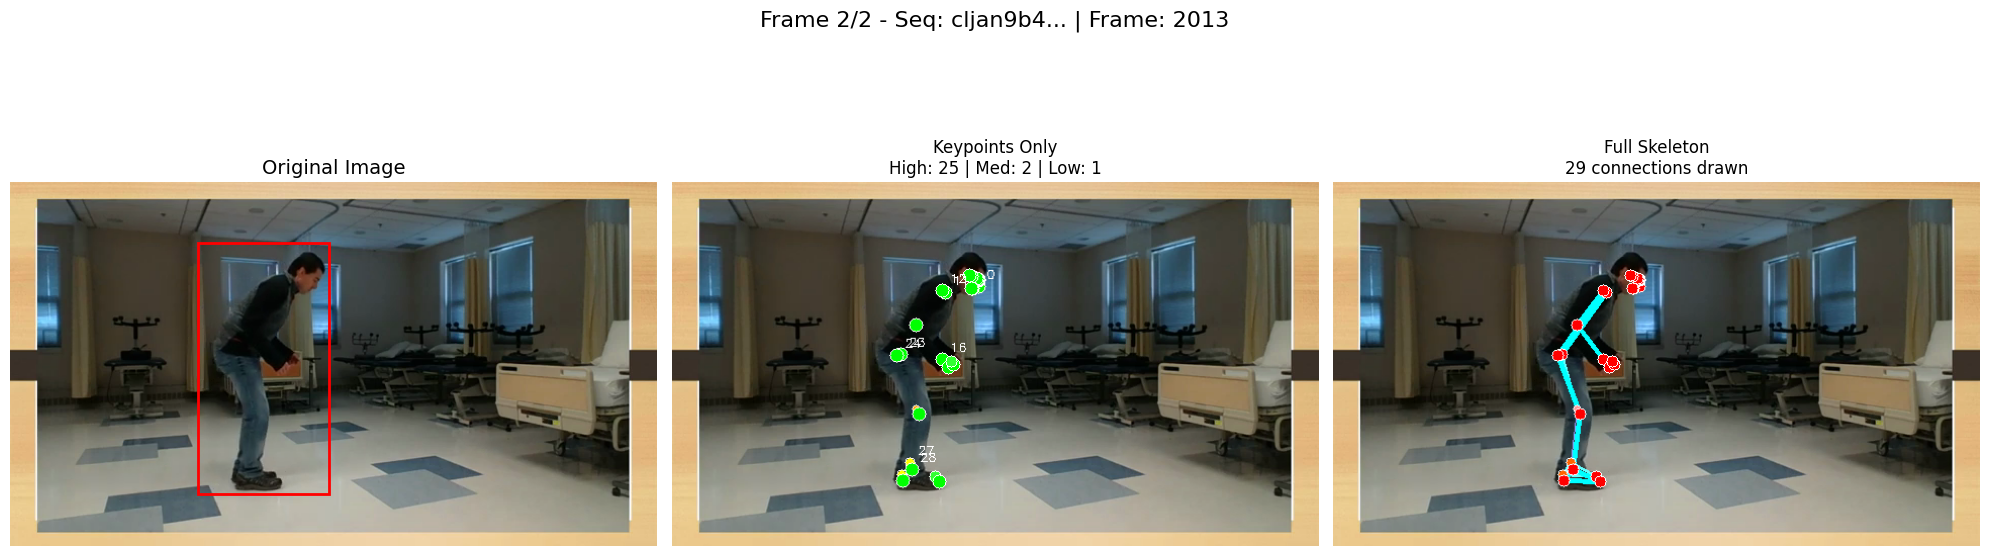


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 27
   High confidence (>0.7): 25
   Medium confidence (0.4-0.7): 2
   Low confidence (0.2-0.4): 1
   Average confidence: 0.773
   Skeleton connections drawn: 29

Body Part Confidence:
   Face (0-10): 0.992
   Upper body (11-22): 0.548
   Lower body (23-32): 0.803

📊 SUMMARY - Tested 2 frames from sequence cljan9b4p00043n6ligceanyp
   ✅ Successful detections: 2/2
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.784

SEQUENCE 2/2: cljanb45y00083n6lmh1qhydd
🎯 Auto-selected 2 frames from sequence (total: 215)

--- Testing frame 1/2 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 0 | Frame number: 2532
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=805.0, top=129.0, w=247.0, h=485.0
   Annot

I0000 00:00:1768337040.402916 5743000 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337040.455564 5743002 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337040.463192 5743002 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


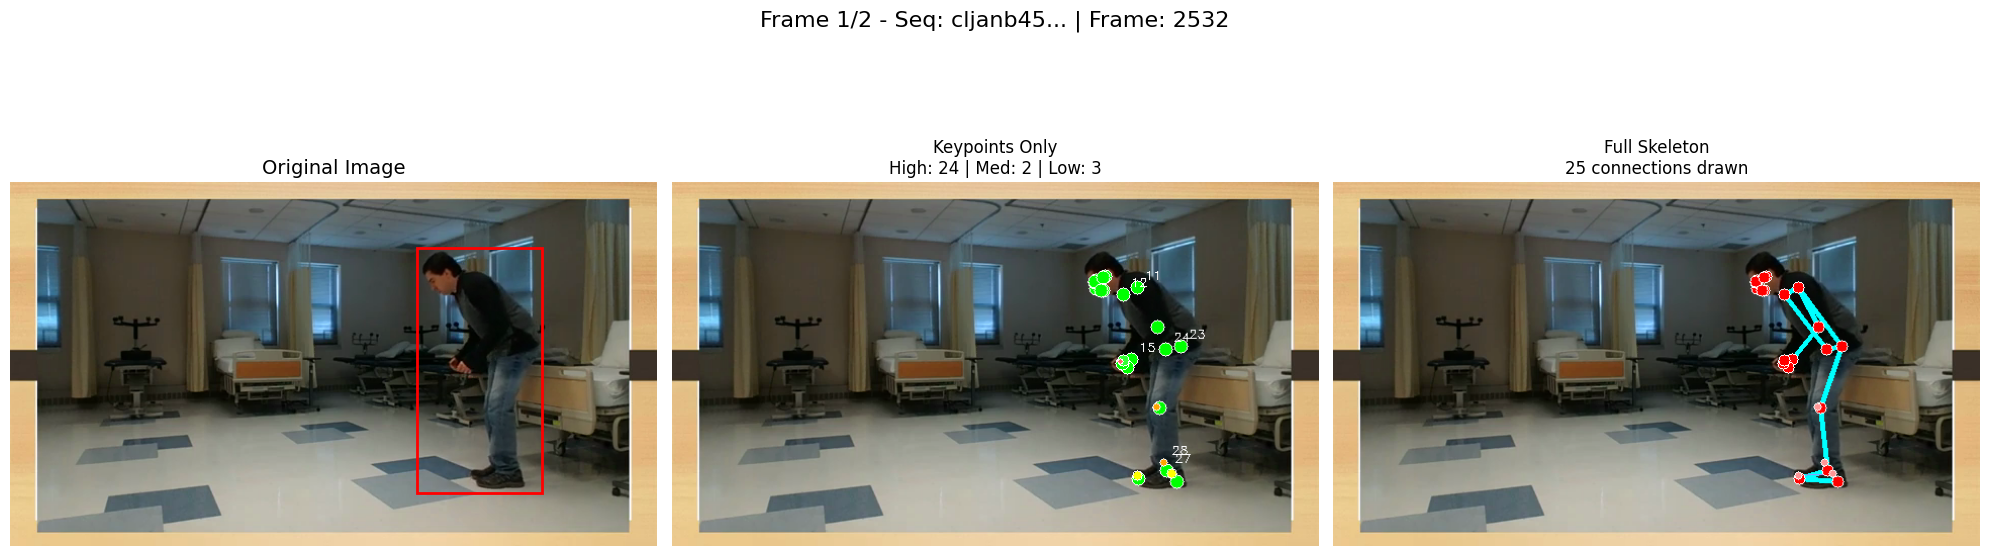


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 24
   High confidence (>0.7): 24
   Medium confidence (0.4-0.7): 2
   Low confidence (0.2-0.4): 3
   Average confidence: 0.738
   Skeleton connections drawn: 25

Body Part Confidence:
   Face (0-10): 0.994
   Upper body (11-22): 0.549
   Lower body (23-32): 0.684

--- Testing frame 2/2 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 107 | Frame number: 2639
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks
🔧 BBOX SCALING APPLIED:
   Original: left=659.2641509433962, top=112.56603773584905, w=278.41509433962267, h=501.13207547169816
   Annotation res: 1280x720
   Actual res: 640x360
   Scale: x=0.500, y=0.500
   Scaled: left=329.6, top=56.3, w=139.2, h=250.6
   ✅ Bounding box drawn with correct scaling


I0000 00:00:1768337040.619817 5743025 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337040.672916 5743028 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337040.680626 5743028 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


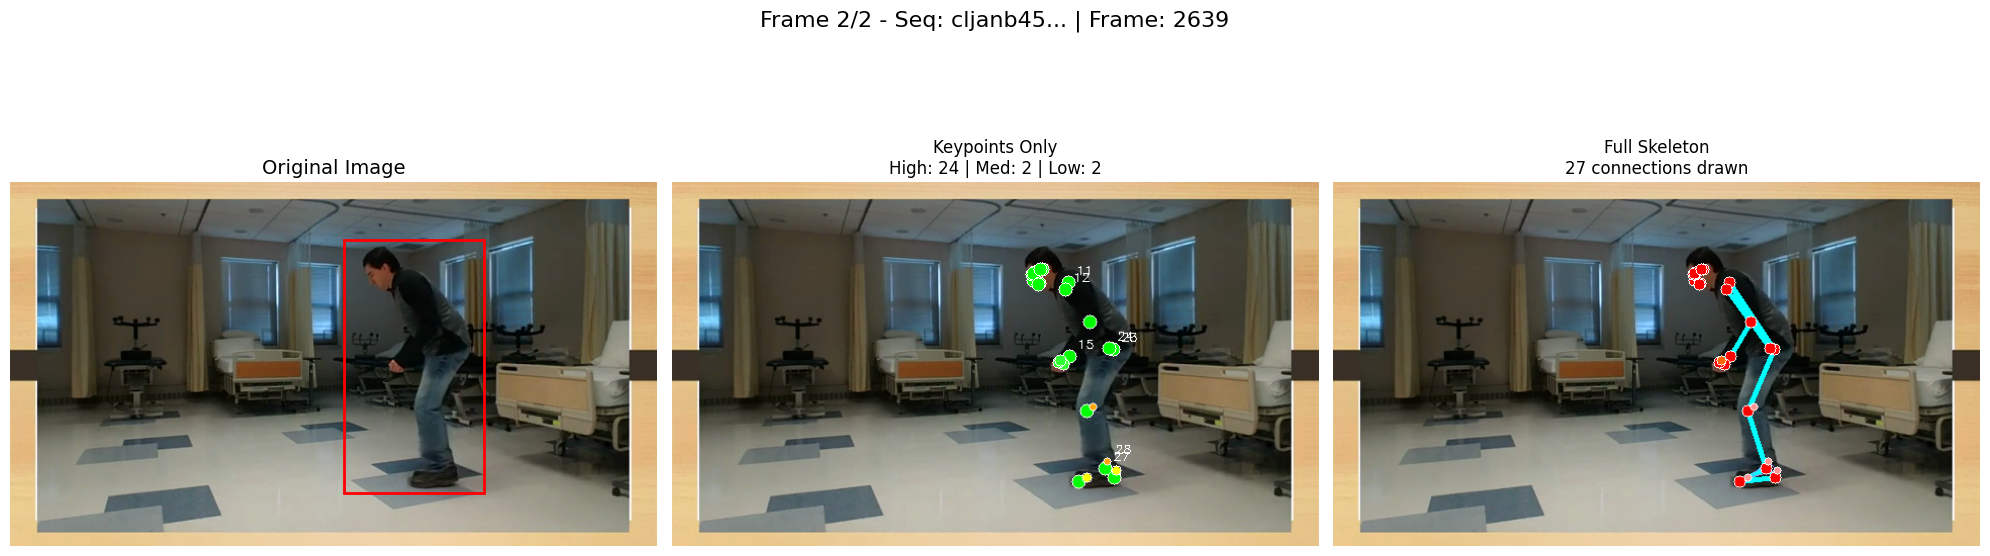


Detailed Pose Analysis:
   Total landmarks: 33
   Visible landmarks (>0.5): 24
   High confidence (>0.7): 24
   Medium confidence (0.4-0.7): 2
   Low confidence (0.2-0.4): 2
   Average confidence: 0.733
   Skeleton connections drawn: 27

Body Part Confidence:
   Face (0-10): 0.997
   Upper body (11-22): 0.516
   Lower body (23-32): 0.703

📊 SUMMARY - Tested 2 frames from sequence cljanb45y00083n6lmh1qhydd
   ✅ Successful detections: 2/2
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.736

OVERALL SUMMARY
📊 Total tests: 4
✅ Successful detections: 4/4 (100.0%)
   cljan9b4p00043n6ligc...: 2/2 successful
   cljanb45y00083n6lmh1...: 2/2 successful


In [21]:
# Quick exploration (2 frames per sequence, with visualizations)
all_results = pose_estimation_all_sequences(
    sequences=sequences, 
    max_frames_per_seq=2, 
    show_visualizations=True
)

In [23]:
all_results = pose_estimation_all_sequences(
    sequences=sequences, 
    max_frames_per_seq=5, 
    show_visualizations=False
)

🔍 Exploring pose detection across 2 sequences
   Testing up to 5 frames per sequence

SEQUENCE 1/2: cljan9b4p00043n6ligceanyp
🎯 Auto-selected 5 frames from sequence (total: 512)

--- Testing frame 1/5 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 0 | Frame number: 1757
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 2/5 ---


I0000 00:00:1768337142.727652 5744462 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337142.784733 5744464 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337142.802696 5744468 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1768337142.856349 5744483 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337142.907516 5744485 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337142.915148 5744486 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 102 | Frame number: 1859
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 3/5 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 204 | Frame number: 1961
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 4/5 ---


I0000 00:00:1768337142.964775 5744503 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.015953 5744507 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.023461 5744504 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1768337143.080126 5744520 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.130920 5744523 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.139212 5744522 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 306 | Frame number: 2063
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 5/5 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljan9b4p00043n6ligceanyp
   Frame index: 408 | Frame number: 2165
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

📊 SUMMARY - Tested 5 frames from sequence cljan9b4p00043n6ligceanyp
   ✅ Successful detections: 5/5
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.788

SEQUENCE 2/2: cljanb45y00083n6lmh1qhydd
🎯 Auto-selected 5 frames from sequence (total: 215)

--- Testing frame 1/5 ---


...

✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 0 | Frame number: 2532
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 2/5 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 43 | Frame number: 2575
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 3/5 ---


I0000 00:00:1768337143.400386 5744571 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.451547 5744575 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.459181 5744575 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1768337143.506710 5744588 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.557438 5744590 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.564912 5744591 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 86 | Frame number: 2618
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 4/5 ---
✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 129 | Frame number: 2661
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

--- Testing frame 5/5 ---


I0000 00:00:1768337143.616715 5744605 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.667979 5744607 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.675400 5744607 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1768337143.729335 5744622 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1768337143.779978 5744624 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768337143.787712 5744624 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Pose Landmarker created from /Users/alexmui/dev/alexpose/data/models/pose_landmarker_full.task
🎯 Processing sequence: cljanb45y00083n6lmh1qhydd
   Frame index: 172 | Frame number: 2704
📹 Frame extracted: (360, 640, 3)
🔍 Running pose detection on full frame...
✅ Detected 33 landmarks

📊 SUMMARY - Tested 5 frames from sequence cljanb45y00083n6lmh1qhydd
   ✅ Successful detections: 5/5
   📈 Average landmarks detected: 33.0
   📈 Average confidence: 0.761

OVERALL SUMMARY
📊 Total tests: 10
✅ Successful detections: 10/10 (100.0%)
   cljan9b4p00043n6ligc...: 5/5 successful
   cljanb45y00083n6lmh1...: 5/5 successful
